# 0. Stock Direction Classifier

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Data Collection

## 1.1 Download data

In [3]:
ticker = "AAPL"

df = yf.download(ticker, start="2010-01-01", end="2024-01-01")

df = df[["Close"]] # We'll only keep the 'Close' column
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2010-01-04,6.406482
2010-01-05,6.417559
2010-01-06,6.315476
2010-01-07,6.303801
2010-01-08,6.345713


## 1.2 Plot closing prices

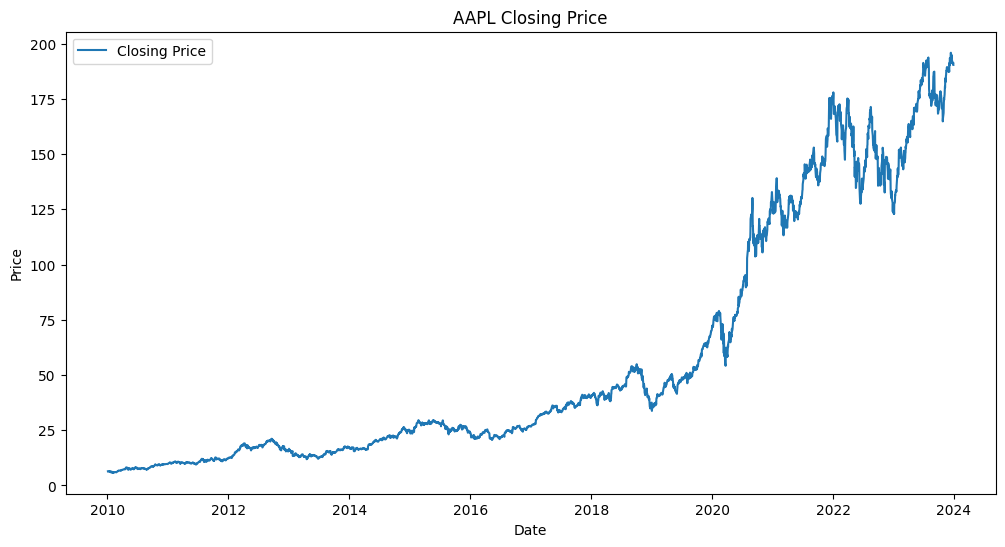

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Close"], label="Closing Price")
plt.title(f"{ticker} Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# 2. Feature Engineering

## 2.1 Log returns

In [5]:
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1)) # Calculate log returns

## 2.2 Technical features

In [6]:
# Moving averages
df["ma_5_ratio"] = df["Close"] / df["Close"].rolling(5).mean()
df["ma_20_ratio"] = df["Close"] / df["Close"].rolling(20).mean()

# Volatility
df["volatility_5"] = df["log_return"].rolling(5).std()
df["volatility_20"] = df["log_return"].rolling(20).std()

# Momentum
df["momentum_5"] = df["log_return"].rolling(5).sum()
df["momentum_20"] = df["log_return"].rolling(20).sum()

# Relative Strength Index (RSI)
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = (-delta.clip(upper=0)).rolling(window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df["rsi"] = compute_rsi(df["Close"])

## 2.3 Target

In [7]:
df["target"] = (df["log_return"].shift(-1) > 0).astype(int) # We will later drop the last row which will have NaN target

In [8]:
count = (df["target"] > 0).sum()
baseline_accuracy = count / len(df) * 100
print(f"Baseline accuracy (predict always 'up'): {baseline_accuracy:.2f}%") # Starting accuracy. Can we beat it?

Baseline accuracy (predict always 'up'): 52.87%


# 3. Getting the data ready

## 3.1 X and y

In [9]:
features = ["log_return", "ma_5_ratio", "ma_20_ratio", "volatility_5", "volatility_20", "momentum_5", "momentum_20", "rsi"]

df_clean = df[features + ["target"]].dropna() # Drop rows with NaN values resulting from rolling calculations
X = df_clean[features]
y = df_clean["target"]

## 3.2 Splitting the data

In [10]:
train_split = (int(len(X) * 0.7))
val_split = (int(len(X) * 0.2))

X_train, y_train = X[:train_split], y[:train_split]
X_val, y_val = X[train_split:train_split+val_split], y[train_split:train_split+val_split]
X_test, y_test = X[train_split+val_split:], y[train_split+val_split:]

len(X_train), len(X_val), len(X_test)

(2451, 700, 351)

## 3.3 Scaling the data

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test) # Only on training data to prevent data leakage

## 3.4 Converting datas to tensor and sending them to the device

In [12]:
# Let's convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).to(device)

## 3.5 Setup DataLoader

In [13]:
# Let's setup the dataloaders
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor) # TensorDataset combines features and labels into a single dataset object
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)


# 4. Build and instantiate a model

In [14]:
from torch import nn

class StockDirectionModel(nn.Module):
    def __init__(self, input_features: int = 8, hidden_units: int = 16, output_features: int = 2):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )

    def forward(self, x):
            return self.linear_layer_stack(x)
        
model = StockDirectionModel(input_features=8,
                            hidden_units=16,
                            output_features=2).to(device)

# 5. Training Loop

## 5.1 Choose a loss function and optimizer

In [15]:
loss_fn = nn.CrossEntropyLoss() # CrossEntropyLoss is used for multi-class classification problems, which is appropriate here since we have two classes (up or down).
optimizer = torch.optim.Adam(model.parameters(),
                             lr=0.001)

## 5.2 Setup an accuracy function

In [16]:
def accuracy_fn(y_pred, y_true):
    predicted_classes = y_pred.argmax(dim=1)
    correct = (predicted_classes == y_true).sum().item()
    return correct / len(y_true) * 100

## 5.3 Train and evaluate the model

In [17]:
torch.manual_seed(42)

epochs = 50

# These lists will store the loss and accuracy values for each epoch, which we can later use for visualization.
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    print(f"Epoch: {epoch}------")
    model.train()
    train_loss, train_acc = 0, 0
    val_loss, val_acc = 0, 0
    for batch, (X_batch, y_batch) in enumerate(train_loader):

        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch.long())
        train_loss += loss.item()
        train_acc += accuracy_fn(y_pred, y_batch.long())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Validation loop
    model.eval()
    val_loss = 0
    with torch.inference_mode():
        for batch, (X_batch, y_batch) in enumerate(val_loader):
            y_pred = model(X_batch)

            loss = loss_fn(y_pred, y_batch.long())
            val_loss += loss.item()
            val_acc += accuracy_fn(y_pred, y_batch.long())

    # Salva i valori
    train_losses.append(train_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))
    train_accs.append(train_acc / len(train_loader))
    val_accs.append(val_acc / len(val_loader))

    print(f"Epoch {epoch} | "
          f"Train loss: {train_losses[-1]:.4f} | "
          f"Train acc: {train_accs[-1]:.2f}% | "
          f"Val loss: {val_losses[-1]:.4f} | "
          f"Val acc: {val_accs[-1]:.2f}%")

Epoch: 0------
Epoch 0 | Train loss: 0.6966 | Train acc: 50.64% | Val loss: 0.6948 | Val acc: 49.88%
Epoch: 1------
Epoch 1 | Train loss: 0.6946 | Train acc: 50.34% | Val loss: 0.6942 | Val acc: 51.32%
Epoch: 2------
Epoch 2 | Train loss: 0.6908 | Train acc: 52.19% | Val loss: 0.6941 | Val acc: 51.89%
Epoch: 3------
Epoch 3 | Train loss: 0.6927 | Train acc: 50.60% | Val loss: 0.6931 | Val acc: 53.02%
Epoch: 4------
Epoch 4 | Train loss: 0.6917 | Train acc: 52.77% | Val loss: 0.6935 | Val acc: 52.17%
Epoch: 5------
Epoch 5 | Train loss: 0.6918 | Train acc: 52.79% | Val loss: 0.6922 | Val acc: 53.88%
Epoch: 6------
Epoch 6 | Train loss: 0.6912 | Train acc: 52.20% | Val loss: 0.6923 | Val acc: 53.59%
Epoch: 7------
Epoch 7 | Train loss: 0.6926 | Train acc: 52.26% | Val loss: 0.6924 | Val acc: 53.59%
Epoch: 8------
Epoch 8 | Train loss: 0.6932 | Train acc: 51.69% | Val loss: 0.6925 | Val acc: 54.02%
Epoch: 9------
Epoch 9 | Train loss: 0.6915 | Train acc: 51.28% | Val loss: 0.6926 | Val ac

# 6. Testing Loop

## 6.1 Let's test the model

In [18]:
model.eval()
test_loss, test_acc = 0, 0
with torch.inference_mode():
    for batch, (X_batch, y_batch) in enumerate(test_loader):
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch.long())
        test_loss += loss.item()
        test_acc += accuracy_fn(y_pred, y_batch.long())

print(f"Test loss: {test_loss/len(test_loader):.4f} | "
      f"Test acc: {test_acc/len(test_loader):.2f}%")

Test loss: 0.6949 | Test acc: 51.01%


## 6.2 Confusion Matrix

              precision    recall  f1-score   support

        Down       0.46      0.20      0.28       167
          Up       0.52      0.79      0.63       184

    accuracy                           0.51       351
   macro avg       0.49      0.50      0.45       351
weighted avg       0.49      0.51      0.46       351



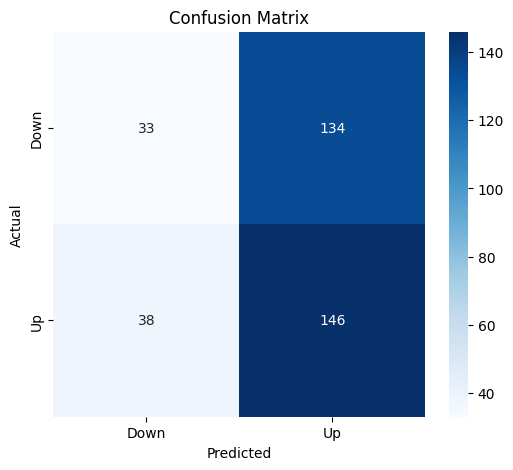

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

all_preds, all_labels = [], []

model.eval()
with torch.inference_mode():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)
        predicted = y_pred.argmax(dim=1)  # Get the predicted class (0 or 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=["Down", "Up"]))

# Confusion matrix visual
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Down", "Up"],
            yticklabels=["Down", "Up"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



# 7. Conclusion

## 7.1 Analysis

I'm afraid that, if the model would have been able to predict the stock market in the slightest, I would not have been here posting this project.
However, on a positive note, this is pretty much in line with the **Efficient Market Hypothesis**!

The model achieves a test accuracy of ~52%, barely above random guessing (50%). This is expected for several reasons:

- **Noisy data**: daily stock returns are influenced by millions of factors (news, geopolitics, macroeconomic events, investor sentiment) that 8 technical indicators simply cannot capture.

- **Efficient Market Hypothesis**: according to the EMH, stock prices already reflect all available public information. If patterns from moving averages and RSI were truly predictive, traders would exploit them until they disappear.

- **Overfitting vs generalization**: during training we observed that the validation loss starts diverging from the training loss after just a few epochs. This confirms that the model struggles to find real patterns and tends to memorize noise when trained for too long.

The confusion matrix further confirms this: the model predicted "Up" for every single day, never once predicting "Down". This is a majority-class collapse: since it cannot find useful patterns, it defaults to always predicting the most frequent class to minimize the loss. 

## 7.2 Accuracy and loss graphs

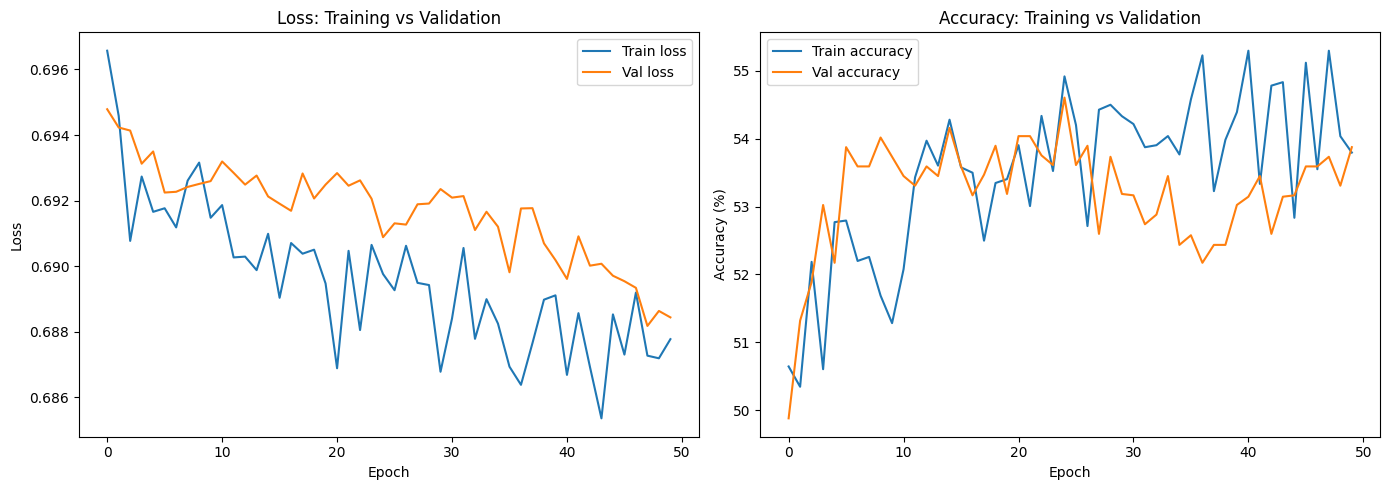

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Grafico loss
ax1.plot(train_losses, label="Train loss")
ax1.plot(val_losses, label="Val loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss: Training vs Validation")
ax1.legend()

# Grafico accuracy
ax2.plot(train_accs, label="Train accuracy")
ax2.plot(val_accs, label="Val accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Accuracy: Training vs Validation")
ax2.legend()

plt.tight_layout()
plt.show()